In [3]:
%cd /content
!git clone -b sentiment-finetuning https://github.com/joony0905/QAIMA.git
%cd /content/QAIMA

/content
Cloning into 'QAIMA'...
remote: Enumerating objects: 5400, done.
remote: Counting objects: 100% (774/774), done.
remote: Compressing objects: 100% (290/290), done.
remote: Total 5400 (delta 512), reused 556 (delta 444), pack-reused 4626 (from 1)
Receiving objects: 100% (5400/5400), 2.45 MiB | 21.78 MiB/s, done.
Resolving deltas: 100% (2980/2980), done.
/content/QAIMA


In [6]:
!ls data/processed
!ls src

finance_sentiment_train.csv  real_news_sentiment_train.csv
dataset.py   inference_test.py	preprocess.py  utils.py
evaluate.py  __init__.py	train.py


In [7]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.1 MB/s eta 0:00:00


In [8]:
!python -m src.train --help

usage: train.py [-h] [--input INPUT] [--output-dir OUTPUT_DIR]
                [--model-name MODEL_NAME] [--stage {first,second}]
                [--max-length MAX_LENGTH] [--epochs EPOCHS]
                [--train-batch-size TRAIN_BATCH_SIZE]
                [--eval-batch-size EVAL_BATCH_SIZE]
                [--learning-rate LEARNING_RATE] [--weight-decay WEIGHT_DECAY]
                [--val-size VAL_SIZE] [--oversample]
                [--oversample-target OVERSAMPLE_TARGET] [--seed SEED]

QAIMA 뉴스 감성 분류 학습 스크립트

options:
  -h, --help            show this help message and exit
  --input INPUT
  --output-dir OUTPUT_DIR
  --model-name MODEL_NAME
  --stage {first,second}
                        학습 단계 메타데이터입니다. second 선택 시 input/output 기본값만 2차용으로
                        바뀝니다.
  --max-length MAX_LENGTH
  --epochs EPOCHS
  --train-batch-size TRAIN_BATCH_SIZE
  --eval-batch-size EVAL_BATCH_SIZE
  --learning-rate LEARNING_RATE
  --weight-decay WEIGHT_DECAY
  --val-size VAL_SIZE
  --oversamp

In [9]:
!python -m src.train \
  --stage first \
  --input data/processed/finance_sentiment_train.csv \
  --output-dir models/kf_deberta_sentiment_v1 \
  --model-name kakaobank/kf-deberta-base \
  --epochs 3 \
  --learning-rate 2e-5

Loaded rows: 4846 (raw: 4846)
Train rows: 4361 (before oversampling: 4361)
Validation rows: 485
Label distribution: {"negative": 604, "neutral": 2879, "positive": 1363}
Train label distribution: {"negative": 543, "neutral": 2591, "positive": 1227}
Validation label distribution: {"negative": 61, "neutral": 288, "positive": 136}
Save path: /content/QAIMA/sentiment_lab/models/kf_deberta_sentiment_v1
config.json: 100% 865/865 [00:00<00:00, 5.28MB/s]
tokenizer_config.json: 100% 374/374 [00:00<00:00, 1.98MB/s]
tokenizer.json: 3.97MB [00:00, 19.1MB/s]
special_tokens_map.json: 100% 173/173 [00:00<00:00, 724kB/s]
pytorch_model.bin: 100% 746M/746M [00:31<00:00, 24.0MB/s]
Loading weights: 100% 198/198 [00:00<00:00, 1229.85it/s, Materializing param=deberta.encoder.rel_embeddings.weight]
DebertaV2ForSequenceClassification LOAD REPORT from: kakaobank/kf-deberta-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.t

In [11]:
!cat models/kf_deberta_sentiment_v1/eval_metrics.json

{
  "eval_loss": 0.5478068590164185,
  "eval_accuracy": 0.843298969072165,
  "eval_macro_f1": 0.832117408175474,
  "eval_negative_f1": 0.8656716417910447,
  "eval_neutral_f1": 0.8767123287671232,
  "eval_positive_f1": 0.753968253968254,
  "eval_runtime": 2.5107,
  "eval_samples_per_second": 193.175,
  "eval_steps_per_second": 24.296,
  "epoch": 3.0
}

In [12]:
!cat models/kf_deberta_sentiment_v1/training_config.json

{
  "stage": "first",
  "input": "/content/QAIMA/sentiment_lab/data/processed/finance_sentiment_train.csv",
  "base_model": "kakaobank/kf-deberta-base",
  "output_dir": "/content/QAIMA/sentiment_lab/models/kf_deberta_sentiment_v1",
  "max_length": 256,
  "epochs": 3.0,
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "val_size": 0.1,
  "oversample": false,
  "oversample_target": null,
  "raw_label_distribution": {
    "negative": 604,
    "neutral": 2879,
    "positive": 1363
  },
  "train_label_distribution": {
    "negative": 543,
    "neutral": 2591,
    "positive": 1227
  },
  "validation_label_distribution": {
    "negative": 61,
    "neutral": 288,
    "positive": 136
  }
}

In [13]:
!python -m src.train \
  --stage second \
  --input data/processed/real_news_sentiment_train.csv \
  --output-dir models/kf_deberta_sentiment_v2 \
  --model-name models/kf_deberta_sentiment_v1 \
  --epochs 2 \
  --train-batch-size 8 \
  --eval-batch-size 8 \
  --learning-rate 1e-5 \
  --oversample \
  --oversample-target 350

Loaded rows: 948 (raw: 948)
Train rows: 1313 (before oversampling: 853)
Validation rows: 95
Label distribution: {"negative": 156, "neutral": 681, "positive": 111}
Train label distribution: {"negative": 350, "neutral": 613, "positive": 350}
Validation label distribution: {"negative": 16, "neutral": 68, "positive": 11}
Save path: /content/QAIMA/sentiment_lab/models/kf_deberta_sentiment_v2
Loading weights: 100% 202/202 [00:00<00:00, 919.42it/s, Materializing param=pooler.dense.weight]
Tokenizing dataset: 100% 1313/1313 [00:00<00:00, 1759.98 examples/s]
Tokenizing dataset: 100% 95/95 [00:00<00:00, 2828.84 examples/s]
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
{'loss': '0.6117', 'grad_norm': '112.4', 'learning_rate': '5.03e-06', 'epoch': '1'}
 50% 165/330 [01:13<00:58,  2.83it/s]
  0% 0/12 [00:00<?, ?it/s]
 17% 2/12 [00:00<00:00, 12.23it/s]
 33% 4/12 [00:00<00:01,  7.94it/s]
 42% 5/12 [00:00<00:00,  7.36it/s]
 50% 6/12 [00:00<00:00

In [14]:
!cat models/kf_deberta_sentiment_v2/eval_metrics.json
!cat models/kf_deberta_sentiment_v2/training_config.json
!ls models/kf_deberta_sentiment_v2

{
  "eval_loss": 0.5954539179801941,
  "eval_accuracy": 0.8315789473684211,
  "eval_macro_f1": 0.7738004013866083,
  "eval_negative_f1": 0.7428571428571429,
  "eval_neutral_f1": 0.8888888888888888,
  "eval_positive_f1": 0.6896551724137931,
  "eval_runtime": 1.8798,
  "eval_samples_per_second": 50.537,
  "eval_steps_per_second": 6.384,
  "epoch": 2.0
}{
  "stage": "second",
  "input": "/content/QAIMA/sentiment_lab/data/processed/real_news_sentiment_train.csv",
  "base_model": "models/kf_deberta_sentiment_v1",
  "output_dir": "/content/QAIMA/sentiment_lab/models/kf_deberta_sentiment_v2",
  "max_length": 256,
  "epochs": 2.0,
  "learning_rate": 1e-05,
  "weight_decay": 0.01,
  "val_size": 0.1,
  "oversample": true,
  "oversample_target": 350,
  "raw_label_distribution": {
    "negative": 156,
    "neutral": 681,
    "positive": 111
  },
  "train_label_distribution": {
    "negative": 350,
    "neutral": 613,
    "positive": 350
  },
  "validation_label_distribution": {
    "negative": 16,

In [15]:
!zip -r kf_deberta_sentiment_v2.zip models/kf_deberta_sentiment_v2

  adding: models/kf_deberta_sentiment_v2/ (stored 0%)
  adding: models/kf_deberta_sentiment_v2/tokenizer.json (deflated 68%)
  adding: models/kf_deberta_sentiment_v2/training_args.bin (deflated 53%)
  adding: models/kf_deberta_sentiment_v2/training_config.json (deflated 56%)
  adding: models/kf_deberta_sentiment_v2/tokenizer_config.json (deflated 52%)
  adding: models/kf_deberta_sentiment_v2/config.json (deflated 57%)
  adding: models/kf_deberta_sentiment_v2/model.safetensors (deflated 19%)
  adding: models/kf_deberta_sentiment_v2/checkpoint-165/ (stored 0%)
  adding: models/kf_deberta_sentiment_v2/checkpoint-165/tokenizer.json (deflated 68%)
  adding: models/kf_deberta_sentiment_v2/checkpoint-165/training_args.bin (deflated 53%)
  adding: models/kf_deberta_sentiment_v2/checkpoint-165/tokenizer_config.json (deflated 52%)
  adding: models/kf_deberta_sentiment_v2/checkpoint-165/config.json (deflated 57%)
  adding: models/kf_deberta_sentiment_v2/checkpoint-165/optimizer.pt (deflated 54%)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Classification Report
              precision    recall  f1-score   support

    negative     0.6842    0.8125    0.7429        16
     neutral     0.9655    0.8235    0.8889        68
    positive     0.5556    0.9091    0.6897        11

    accuracy                         0.8316        95
   macro avg     0.7351    0.8484    0.7738        95
weighted avg     0.8707    0.8316    0.8412        95



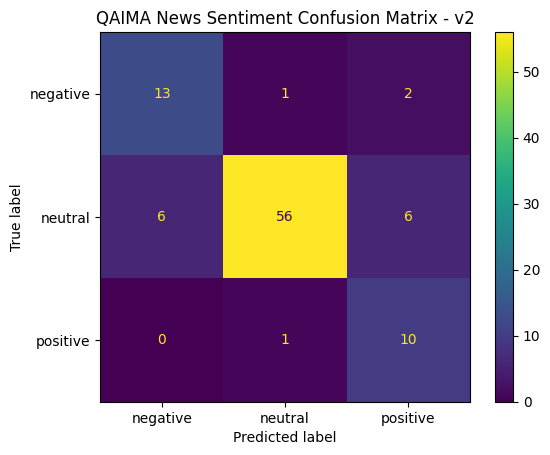

In [16]:
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_DIR = "models/kf_deberta_sentiment_v2"
DATA_PATH = "data/processed/real_news_sentiment_train.csv"

df = pd.read_csv(DATA_PATH)

# label이 숫자면 문자로 변환
label_map = {
    0: "negative",
    1: "neutral",
    2: "positive",
    "0": "negative",
    "1": "neutral",
    "2": "positive",
    "negative": "negative",
    "neutral": "neutral",
    "positive": "positive",
}
df["label_name"] = df["label"].map(label_map)

# train.py와 같은 validation split
train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42,
    stratify=df["label_name"]
)

labels = ["negative", "neutral", "positive"]
label_to_id = {label: i for i, label in enumerate(labels)}
id_to_label = {i: label for label, i in label_to_id.items()}

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

texts = val_df["text"].tolist()
y_true = val_df["label_name"].tolist()

preds = []
batch_size = 16

for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i+batch_size]

    inputs = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits
        pred_ids = torch.argmax(logits, dim=-1).cpu().numpy()

    preds.extend([id_to_label[int(x)] for x in pred_ids])

cm = confusion_matrix(y_true, preds, labels=labels)

print("Classification Report")
print(classification_report(y_true, preds, labels=labels, digits=4))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d")
plt.title("QAIMA News Sentiment Confusion Matrix - v2")
plt.show()